In [1]:
import pandas as pd
# 建立一個範例 DataFrame
data = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']
})
one_hot_df = pd.get_dummies(data,columns=["Color"])
one_hot_df

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,False,True,False
2,True,False,False
3,False,True,False
4,False,False,True


In [2]:
## OneHotEncoder
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


In [4]:
# 建立一個範例 DataFrame
data = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']
})
ohe = OneHotEncoder()
on_hot_code = ohe.fit_transform(data[['Color']])
print(on_hot_code)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>
  Coords	Values
  (0, 2)	1.0
  (1, 1)	1.0
  (2, 0)	1.0
  (3, 1)	1.0
  (4, 2)	1.0


In [7]:
ohe = OneHotEncoder(sparse_output=False)
on_hot_code = ohe.fit_transform(data[['Color']])
print(on_hot_code)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [20]:
colName = ohe.get_feature_names_out()
print(colName)
one_hot_df = pd.DataFrame(on_hot_code,columns=colName)
print(one_hot_df)
one_hot_df.drop("Color_Green",axis=1,inplace=True)
one_hot_df

['Color_Blue' 'Color_Green' 'Color_Red']
   Color_Blue  Color_Green  Color_Red
0         0.0          0.0        1.0
1         0.0          1.0        0.0
2         1.0          0.0        0.0
3         0.0          1.0        0.0
4         0.0          0.0        1.0


,Color_Blue,Color_Red
0,0.0,1.0
1,0.0,0.0
2,1.0,0.0
3,0.0,0.0
4,0.0,1.0


# 共線性(Collinearity)

In [21]:
import pandas as pd
# 建立一個範例 DataFrame
data = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']
})
one_hot_df = pd.get_dummies(data,columns=["Color"],drop_first=True)
one_hot_df

,Color_Green,Color_Red
0,False,True
1,True,False
2,False,False
3,True,False
4,False,True


在數據分析和機器學習中，數據類型可以大致分為以下幾種，每種都有其特定的用途和處理方式：

1. **類別數據（Categorical Data）**
   - **說明**：表示不同類別或群組的數據，通常是非數值的。
   - **案例**：性別（男、女）、血型（A、B、AB、O）、產品類型（家具、電子產品、服裝）。

2. **數值數據（Numerical Data）**
   - 分為兩種：
     - **連續數據（Continuous Data）**
       - **說明**：可以在一定範圍內任意細分的數據。
       - **案例**：身高、體重、溫度、股票價格。
     - **離散數據（Discrete Data）**
       - **說明**：具體的整數值，不可以細分。
       - **案例**：班上學生人數、公司員工數、一天中的客戶服務電話次數。

3. **時間數據（Time Series Data）**
   - **說明**：按時間順序排列的數據點序列，通常每個數據點都有一個時間戳。
   - **案例**：每日股市收盤價、每小時天氣記錄、月銷售數據。

4. **文字數據（Text Data）**
   - **說明**：由字、詞、句子構成的數據，通常需要特殊的處理方式如自然語言處理（NLP）。
   - **案例**：商品評論、新聞文章、社交媒體帖子。

5. **布爾數據（Boolean Data）**
   - **說明**：表示是或否的二元數據。
   - **案例**：是否已婚（是、否）、是否訂閱電子報（是、否）。

6. **序列數據（Ordinal Data）**
   - **說明**：類別數據的一種，但類別之間存在自然排序或等級。
   - **案例**：滿意度調查（不滿意、一般、滿意、非常滿意）、教育程度（小學、中學、大學、研究生）。

這些數據類型在數據分析和機器學習中扮演著關鍵角色，根據數據的特性選擇適當的處理方式對於獲得有效的分析結果至關重要。

In [22]:
import pandas as pd
df = pd.read_csv("./Ames_NO_Missing_Data.csv")
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   int64  
 1   MS Zoning        2925 non-null   str    
 2   Lot Frontage     2925 non-null   float64
 3   Lot Area         2925 non-null   int64  
 4   Street           2925 non-null   str    
 5   Lot Shape        2925 non-null   str    
 6   Land Contour     2925 non-null   str    
 7   Utilities        2925 non-null   str    
 8   Lot Config       2925 non-null   str    
 9   Land Slope       2925 non-null   str    
 10  Neighborhood     2925 non-null   str    
 11  Condition 1      2925 non-null   str    
 12  Condition 2      2925 non-null   str    
 13  Bldg Type        2925 non-null   str    
 14  House Style      2925 non-null   str    
 15  Overall Qual     2925 non-null   int64  
 16  Overall Cond     2925 non-null   int64  
 17  Year Built       2925 non

當我們將類別數據以數字形式編碼時需要小心。我們需要確保數字之間的關係對模型來說是有意義的。例如，MSSubClass 的編碼本質上只是每個類別的數字代碼：

**MSSubClass: 住宅類型。**

- **20**	1-STOREY 1946 & NEWER ALL STYLES 一層樓 1946年及以後所有風格
- **30**	1-STOREY 1945 & OLDER 一層樓 1945年及更早
- **40**	1-STOREY W/FINISHED ATTIC ALL AGES 一層樓帶完成的閣樓 所有年齡
- **45**	1-1/2 STORY - UNFINISHED ALL AGES 一層半未完成 所有年齡
- **50**	1-1/2 STORY FINISHED ALL AGES 一層半完成 所有年齡
- **60**	2-STORY 1946 & NEWER 二層樓 1946年及以後
- **70**	2-STORY 1945 & OLDER 二層樓 1945年及更早
- **75**	2-1/2 STORY ALL AGES 二層半 所有年齡
- **80**	SPLIT OR MULTI-LEVEL 分割或多層
- **85**	SPLIT FOYER 分割門廳
- **90**	DUPLEX - ALL STYLES AND AGES 雙拼 - 所有風格和年齡
- **120**	1-STORY PUD (Planned Unit Development) - 1946 & NEWER 一層樓PUD（計劃單元開發）- 1946年及以後
- **150**	1-1/2 STORY PUD - ALL AGES 一層半PUD - 所有年齡
- **160**	2-STORY PUD - 1946 & NEWER 二層樓PUD - 1946年及以後
- **180**	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER PUD - 多層 - 包括分割層/門廳
- **190**	2 FAMILY CONVERSION - ALL STYLES AND AGES 兩家庭改造 - 所有風格和年齡

數字本身似乎並無與其他數字相關。雖然 30 > 20 是對的，但“1-STOREY 1945 & OLDER” > “1-STOREY 1946 & NEWER ALL STYLES”實際上並無意義。需要注意的是，這並不總是這樣，例如將頭等艙和二等艙編碼為 1 和 2 的情況。確保你完全理解你的數據集，以檢查需要轉換/更改的內容。

In [24]:
df["MS SubClass"] = df["MS SubClass"].astype(str)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   str    
 1   MS Zoning        2925 non-null   str    
 2   Lot Frontage     2925 non-null   float64
 3   Lot Area         2925 non-null   int64  
 4   Street           2925 non-null   str    
 5   Lot Shape        2925 non-null   str    
 6   Land Contour     2925 non-null   str    
 7   Utilities        2925 non-null   str    
 8   Lot Config       2925 non-null   str    
 9   Land Slope       2925 non-null   str    
 10  Neighborhood     2925 non-null   str    
 11  Condition 1      2925 non-null   str    
 12  Condition 2      2925 non-null   str    
 13  Bldg Type        2925 non-null   str    
 14  House Style      2925 non-null   str    
 15  Overall Qual     2925 non-null   int64  
 16  Overall Cond     2925 non-null   int64  
 17  Year Built       2925 non

In [28]:
df_nums = df.select_dtypes(exclude=["object"])
df_obj = df.select_dtypes(include=["object"])
df_nums.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Lot Frontage     2925 non-null   float64
 1   Lot Area         2925 non-null   int64  
 2   Overall Qual     2925 non-null   int64  
 3   Overall Cond     2925 non-null   int64  
 4   Year Built       2925 non-null   int64  
 5   Year Remod/Add   2925 non-null   int64  
 6   Mas Vnr Area     2925 non-null   float64
 7   BsmtFin SF 1     2925 non-null   float64
 8   BsmtFin SF 2     2925 non-null   float64
 9   Bsmt Unf SF      2925 non-null   float64
 10  Total Bsmt SF    2925 non-null   float64
 11  1st Flr SF       2925 non-null   int64  
 12  2nd Flr SF       2925 non-null   int64  
 13  Low Qual Fin SF  2925 non-null   int64  
 14  Gr Liv Area      2925 non-null   int64  
 15  Bsmt Full Bath   2925 non-null   float64
 16  Bsmt Half Bath   2925 non-null   float64
 17  Full Bath        2925 non

C:\Users\xvpow\AppData\Local\Temp\ipykernel_10216\2151242436.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_obj = df.select_dtypes(include=["object"])


In [29]:
df_obj.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   MS SubClass     2925 non-null   str  
 1   MS Zoning       2925 non-null   str  
 2   Street          2925 non-null   str  
 3   Lot Shape       2925 non-null   str  
 4   Land Contour    2925 non-null   str  
 5   Utilities       2925 non-null   str  
 6   Lot Config      2925 non-null   str  
 7   Land Slope      2925 non-null   str  
 8   Neighborhood    2925 non-null   str  
 9   Condition 1     2925 non-null   str  
 10  Condition 2     2925 non-null   str  
 11  Bldg Type       2925 non-null   str  
 12  House Style     2925 non-null   str  
 13  Roof Style      2925 non-null   str  
 14  Roof Matl       2925 non-null   str  
 15  Exterior 1st    2925 non-null   str  
 16  Exterior 2nd    2925 non-null   str  
 17  Mas Vnr Type    1152 non-null   str  
 18  Exter Qual      2925 non-null   str  
 

In [30]:
df_objs = pd.get_dummies(df_obj,drop_first=True)
df_objs

,MS SubClass_150,MS SubClass_160,MS SubClass_180,MS SubClass_190,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2921,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2922,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2923,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [31]:
final_df = df_nums.join(df_objs)
final_df

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.000000,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,False,False,False,False,True,False,False,False,True,False
1,80.000000,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,False,False,False,False,True,False,False,False,True,False
2,81.000000,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,False,False,False,False,True,False,False,False,True,False
3,93.000000,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,False,False,False,False,True,False,False,False,True,False
4,74.000000,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,37.000000,7937,6,6,1984,1984,0.0,819.0,0.0,184.0,...,False,False,False,False,True,False,False,False,True,False
2921,75.144444,8885,5,5,1983,1983,0.0,301.0,324.0,239.0,...,False,False,False,False,True,False,False,False,True,False
2922,62.000000,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,False,False,False,False,True,False,False,False,True,False
2923,77.000000,10010,5,5,1974,1975,0.0,1071.0,123.0,195.0,...,False,False,False,False,True,False,False,False,True,False


# MinMaxScaler
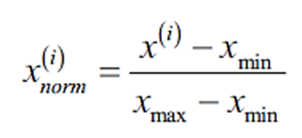

In [32]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

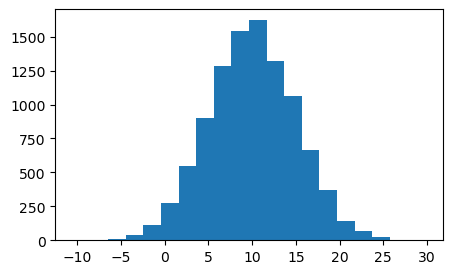

In [38]:
data = np.random.normal(10,5,10000)#平均值10 標準差 5 樣本數10000
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

## 轉換

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
minMaxScalerObj = scaler.fit(data.reshape(-1,1))


In [41]:
data_new = minMaxScalerObj.transform(data.reshape(-1,1))
data_new

array([[0.47982402],
       [0.5367596 ],
       [0.68928091],
       ...,
       [0.40370984],
       [0.45740776],
       [0.5024256 ]], shape=(10000, 1))

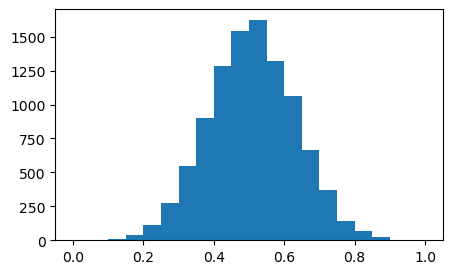

In [42]:
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

## 均勻分配轉換

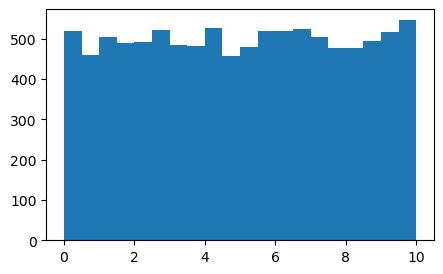

In [53]:
data = np.random.uniform(0,10,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

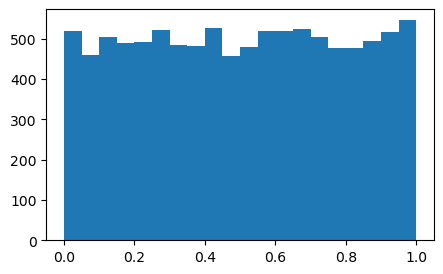

In [54]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

## Gamma分配轉換

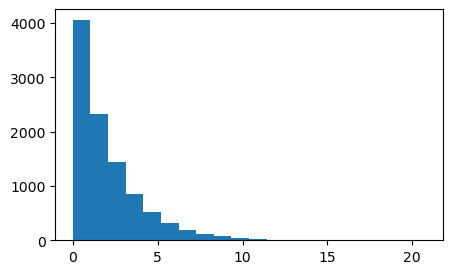

In [69]:
data = np.random.gamma(1,2,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

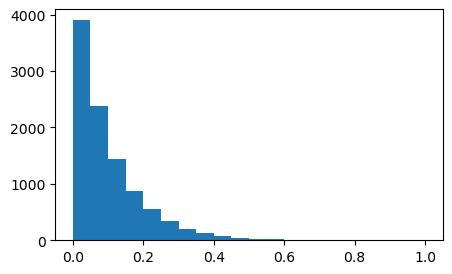

In [62]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

# 鳶尾花(Iris)品種的辨識

In [63]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [64]:
X,y = datasets.load_iris(return_X_y=True)
X,y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((120, 4), (30, 4), (120,), (30,))

## 特徵縮放

In [71]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 選擇演算法

In [72]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

# 模型訓練

In [73]:
clf.fit(X_train_std,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 模型評估

In [74]:
y_pred = clf.predict(X_test_std)
y_pred

array([0, 2, 0, 2, 0, 2, 0, 0, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 0, 1, 0, 2,
       1, 2, 1, 0, 2, 2, 1, 1])

In [75]:
print(f"{accuracy_score(y_test,y_pred) * 100:.2f}")

96.67


## StandardScaler 特徵縮放
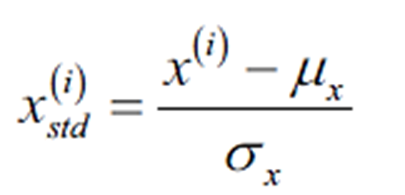

## 載入相關套件

In [76]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [84]:
X,y = datasets.load_iris(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [86]:
clf = LogisticRegression()
clf.fit(X_train_std,y_train)
y_pred = clf.predict(X_test_std)

In [87]:
print(f"{accuracy_score(y_test,y_pred) * 100:.2f}")

93.33


In [88]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

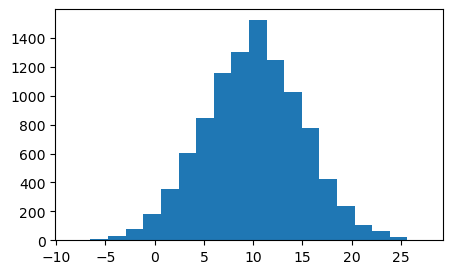

In [89]:
data = np.random.normal(10,5,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)  
plt.show()

## 轉換

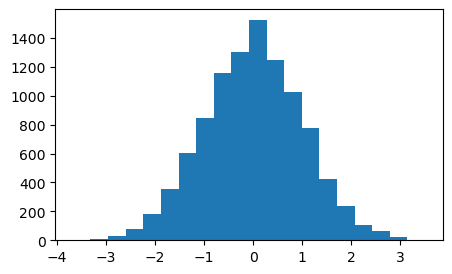

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

## 均勻分配轉換

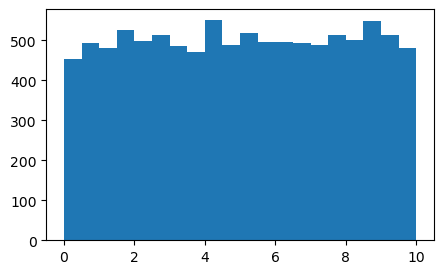

In [91]:
data = np.random.uniform(0,10,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

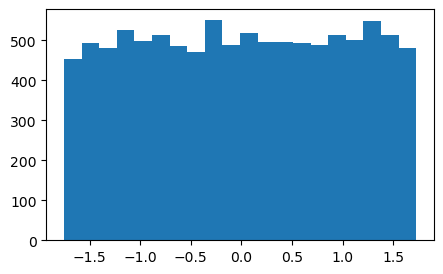

In [92]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()

## Gamma分配轉換

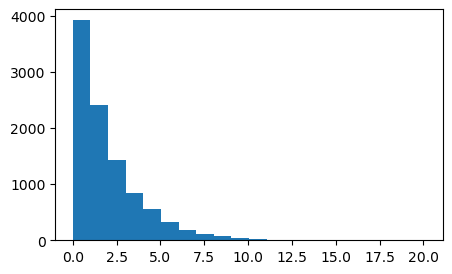

In [93]:
data = np.random.gamma(1,2,10000)
plt.figure(figsize=(5,3))
plt.hist(data,20)
plt.show()

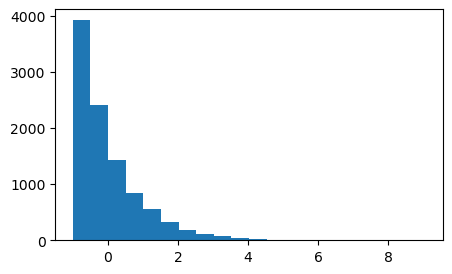

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_new = scaler.fit_transform(data.reshape(-1,1))
plt.figure(figsize=(5,3))
plt.hist(data_new,20)
plt.show()


In [95]:
from sklearn.preprocessing import StandardScaler
data = [[-1, 2],
         [-0.5, 6], 
         [0, 10], 
         [1, 18]]
scaler = StandardScaler(with_mean=True,with_std=True)
scaler.fit(data)
print(scaler.mean_,scaler.var_)

[-0.125  9.   ] [ 0.546875 35.      ]


In [96]:
data_new  = scaler.transform(data)
print(data_new)

[[-1.18321596 -1.18321596]
 [-0.50709255 -0.50709255]
 [ 0.16903085  0.16903085]
 [ 1.52127766  1.52127766]]


## 使用NumPy驗算

## 驗算平均數與標準差 是否跟 StandardScaler 類似

## 手動完成StandardScaler